# 07b — LSTM hyperparameter search on the leakage-free matrix

**Why this notebook.** Notebook 07 refits every model with the hyperparameters selected in the submitted
version, so that the only change is the imputation. For the LSTM that is not enough: its configuration
was searched on the old (interpolated) matrix with an unseeded sampler, and it is the one model that the
rolling-origin evaluation does not re-tune. This notebook repeats the submitted LSTM search on the
leakage-free matrix, under the same protocol:

| | submitted search | this notebook |
|---|---|---|
| objective | RMSE on the 2023 validation year | same |
| search space | window 1–30, 1–5 layers, 32–1024 units, dropout 0–0.7, lr 1e-5–1e-2, batch 16–512 | same |
| architecture | stacked LSTM + BatchNorm + Dropout, linear output | same |
| early stopping | patience 5 (search), 20 (final fit) on 2023 | same |
| sampler | TPE, no seed, 400 trials | TPE, **seed 42**, `N_TRIALS` (resumable) |
| final model | one fit | **five seeds**, forecasts averaged; spread reported |
| windows | built inside each split | built on the full calendar, so 2023/2024 windows may use earlier days' predictors |

The 2024 test year is used once, after the search. The submitted configuration is also refitted (five seeds,
same architecture) for comparison.

**Run:** after 07, before 09 · **GPU** · ~1–1.5 h for 100 trials on a T4 (resumable: re-run to continue,
raise `N_TRIALS` to extend). **Never run with `SARKOY_FAST=1` in the real folder** (it would store toy trials
in the study).

**Outputs:** updates the `LSTM` column of `original_protocol_predictions.csv` (a backup is kept) and adds
`LSTM (submitted configuration)`; `tables/S13_lstm_search.csv`, `tables/S13_lstm_seeds.csv`,
`figures/figS_lstm_search`, `models/lstm_study.db`, values in `results_07b.json`.

In [8]:
# --- Setup: Drive, paths, shared helpers -------------------------------------------------------
import os, sys, json, time, warnings, subprocess
warnings.filterwarnings('ignore')
try:
    from google.colab import drive
    drive.mount('/content/drive')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'optuna', 'shap', 'scienceplots',
                    'ephem', 'catboost', 'lightgbm'], check=False)
except Exception:
    pass
_BASE = os.environ.get('SARKOY_BASE', '/content/drive/MyDrive/windforecast_rev1/')
sys.path.insert(0, os.path.join(_BASE, 'revision'))
if not os.path.exists(os.path.join(_BASE, 'revision', 'revision_utils.py')):
    raise FileNotFoundError('Copy revision_utils.py into ' + os.path.join(_BASE, 'revision') + ' first.')
import revision_utils as ru
import numpy as np, pandas as pd, matplotlib.pyplot as plt
BASE, REV, IN_COLAB, FAST = ru.get_paths()
ru.set_style()
RES = ru.Results(REV)
RES.path = REV + 'results_07b.json'
GPU = ru.has_gpu()
try:
    from IPython.display import display
except Exception:
    display = print
print('BASE:', BASE, '| REV:', REV, '| GPU:', GPU, '| FAST (smoke test):', FAST)
print(ru.log_versions(REV))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE: /content/drive/MyDrive/windforecast_rev1/ | REV: /content/drive/MyDrive/windforecast_rev1/revision/ | GPU: True | FAST (smoke test): False
{'python': '3.13.15', 'numpy': '2.1.3', 'pandas': '2.2.3', 'sklearn': '1.6.1', 'scipy': '1.16.3', 'xgboost': '3.4.1', 'lightgbm': '4.6.0', 'catboost': '1.2.10', 'optuna': '5.0.0', 'shap': '0.52.0', 'statsmodels': '0.15.0', 'matplotlib': '3.10.0', 'seaborn': '0.13.2', 'pyarrow': '23.0.1', 'ephem': '4.2.1', 'tensorflow': '2.20.0', 'gpu': True}


In [9]:
# --- Configuration --------------------------------------------------------------------------------
import tempfile, shutil, gc
N_TRIALS = 3 if FAST else 400            # completed trials to reach; 400 matches the submitted budget
SEEDS = [42] if FAST else [42, 43, 44, 45, 46]
EPOCHS_SEARCH, PATIENCE_SEARCH = (2, 1) if FAST else (100, 5)
EPOCHS_FINAL, PATIENCE_FINAL = (2, 1) if FAST else (200, 20)
WIN_MAX, LAYERS_MAX, UNITS_MAX = (3, 2, 64) if FAST else (30, 5, 1024)
SUBMITTED_CFG = dict(window_size=1, num_layers=3, num_units=416, dropout_rate=0.09876585985584417,
                     learning_rate=0.0012561075381468112, batch_size=128)
STUDY_NAME = 'lstm_causal_v1'
LOCAL_DB = os.path.join('/content' if IN_COLAB else tempfile.gettempdir(), 'lstm_study.db')
DRIVE_DB = REV + 'models/lstm_study.db'
print('trials:', N_TRIALS, '| seeds:', SEEDS, '| GPU:', GPU)


trials: 400 | seeds: [42, 43, 44, 45, 46] | GPU: True


In [10]:
# --- Data: leakage-free matrix, month-wise scaling fitted on training rows only -------------------
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
df = ru.load_matrix(BASE, REV, 'causal')
X = ru.get_X(df); y = df[ru.TARGET]; ok = df['target_observed'].astype(bool)
yr = df.index.year
tr = (ok & (yr <= 2022)).to_numpy(); va = (ok & (yr == 2023)).to_numpy(); te = (ok & (yr == 2024)).to_numpy()
sc = ru.MonthScaled(None)
sc._tx(X[tr], fit=True)
Z = np.asarray(sc._tx(X), dtype='float32')
y_np = y.to_numpy(dtype='float32')
print('rows', Z.shape, '| train', tr.sum(), '| validation', va.sum(), '| test', te.sum())

def make_windows(w):
    """Sample for day t = predictors of days t-w+1 ... t (all known at the forecast origin)."""
    W = np.lib.stride_tricks.sliding_window_view(Z, w, axis=0).transpose(0, 2, 1)   # (n-w+1, w, f)
    rows = np.arange(w - 1, len(Z))
    return W, rows

def build(w, n_layers, units, dropout):
    inp = layers.Input(shape=(w, Z.shape[1])); h = inp
    for i in range(n_layers):
        h = layers.LSTM(units, return_sequences=(i < n_layers - 1))(h)
        h = layers.BatchNormalization()(h)
        h = layers.Dropout(dropout)(h)
    return models.Model(inp, layers.Dense(1)(h))

def fit_predict(cfg, seed, epochs, patience):
    tf.keras.backend.clear_session(); gc.collect()
    tf.keras.utils.set_random_seed(seed)
    W, rows = make_windows(cfg['window_size'])
    mtr, mva = tr[rows], va[rows]
    net = build(cfg['window_size'], cfg['num_layers'], cfg['num_units'], cfg['dropout_rate'])
    net.compile(optimizer=optimizers.Adam(cfg['learning_rate']), loss='mse')
    net.fit(W[mtr], y_np[rows][mtr], validation_data=(W[mva], y_np[rows][mva]), epochs=epochs,
            batch_size=cfg['batch_size'], verbose=0,
            callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)])
    p = np.full(len(Z), np.nan)
    p[rows] = net.predict(W, batch_size=1024, verbose=0).ravel()
    return p


Loaded causal matrix: (2964, 564), 2016-11-19 -> 2024-12-30, observed targets: 2957
rows (2964, 559) | train 2229 | validation 364 | test 364


In [11]:
# --- Resumable Optuna search (objective: RMSE on the 2023 validation year) -------------------------
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
if os.path.exists(DRIVE_DB) and not os.path.exists(LOCAL_DB):
    shutil.copy(DRIVE_DB, LOCAL_DB)                      # continue a study started in an earlier session
study = optuna.create_study(study_name=STUDY_NAME, storage='sqlite:///' + LOCAL_DB, load_if_exists=True,
                            direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))

def objective(trial):
    cfg = dict(window_size=trial.suggest_int('window_size', 1, WIN_MAX),
               num_layers=trial.suggest_int('num_layers', 1, LAYERS_MAX),
               num_units=trial.suggest_int('num_units', 32, UNITS_MAX, step=32),
               dropout_rate=trial.suggest_float('dropout_rate', 0.0, 0.7),
               learning_rate=trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True),
               batch_size=trial.suggest_categorical('batch_size', [16, 32, 64, 128, 256, 512]))
    try:
        p = fit_predict(cfg, 42, EPOCHS_SEARCH, PATIENCE_SEARCH)
        return ru.rmse(y_np[va], p[va])
    except Exception as e:                               # e.g. memory for the largest configurations
        print('trial failed:', repr(e)[:160])
        return float('nan')                              # recorded as FAIL, not as a completed trial

t0 = time.time()
def backup(study, trial):
    shutil.copy(LOCAL_DB, DRIVE_DB)
    n = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
    if n % 5 == 0:
        print(f'{n} completed trials | best validation RMSE {study.best_value:.4f} | {(time.time() - t0) / 60:.0f} min')

done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
print('completed so far:', done)
if done < N_TRIALS:
    study.optimize(objective, n_trials=N_TRIALS - done, callbacks=[backup], gc_after_trial=True)
shutil.copy(LOCAL_DB, DRIVE_DB)
trials = study.trials_dataframe()
trials.to_csv(REV + 'tables/S13_lstm_search.csv', index=False)
best = dict(study.best_params)
print('best configuration:', best, '| validation RMSE', round(study.best_value, 4))


completed so far: 100
105 completed trials | best validation RMSE 1.0589 | 1 min
110 completed trials | best validation RMSE 1.0589 | 2 min
115 completed trials | best validation RMSE 1.0589 | 3 min
120 completed trials | best validation RMSE 1.0589 | 4 min
125 completed trials | best validation RMSE 1.0589 | 5 min
130 completed trials | best validation RMSE 1.0589 | 6 min
135 completed trials | best validation RMSE 1.0589 | 7 min
140 completed trials | best validation RMSE 1.0589 | 8 min
145 completed trials | best validation RMSE 1.0589 | 9 min
150 completed trials | best validation RMSE 1.0589 | 10 min
155 completed trials | best validation RMSE 1.0589 | 12 min
160 completed trials | best validation RMSE 1.0589 | 13 min
165 completed trials | best validation RMSE 1.0589 | 14 min
170 completed trials | best validation RMSE 1.0589 | 15 min
175 completed trials | best validation RMSE 1.0589 | 16 min
180 completed trials | best validation RMSE 1.0589 | 17 min
185 completed trials | best

saved figure figS_lstm_search


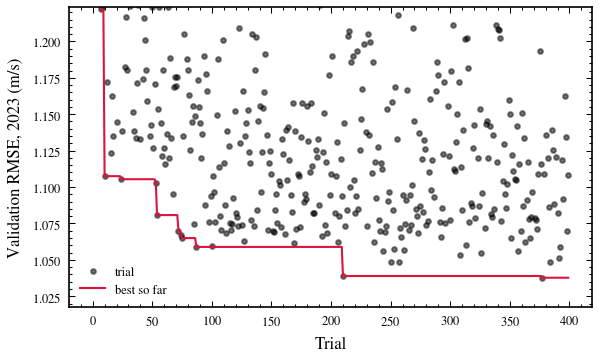

In [12]:
# --- Search history (supplementary figure) --------------------------------------------------------
comp = trials[trials.state == 'COMPLETE'].sort_values('number')
fig, ax = plt.subplots(figsize=(4.5, 2.6))
ax.scatter(comp.number, comp.value, s=5, alpha=0.5, label='trial')
ax.plot(comp.number, comp.value.cummin(), color='crimson', lw=1, label='best so far')
ax.set_ylim(comp.value.min() - 0.02, min(comp.value.quantile(0.9), comp.value.min() + 0.5))
ax.set_xlabel('Trial'); ax.set_ylabel('Validation RMSE, 2023 (m/s)'); ax.legend(frameon=False)
ru.savefig(fig, REV, 'figS_lstm_search'); plt.show()


In [13]:
# --- Final fits: selected and submitted configurations, five seeds each ---------------------------
rows_out, preds = [], {}
for label, cfg in (('LSTM', best), ('LSTM (submitted configuration)', SUBMITTED_CFG)):
    P = []
    for s in SEEDS:
        p = fit_predict(cfg, s, EPOCHS_FINAL, PATIENCE_FINAL)
        P.append(p)
        rows_out.append(dict(config=label, seed=s, val_RMSE=ru.rmse(y_np[va], p[va]),
                             test_RMSE=ru.rmse(y_np[te], p[te]), **{k: cfg[k] for k in cfg}))
        print(f'{label:32s} seed {s}: validation {rows_out[-1]["val_RMSE"]:.4f} | test {rows_out[-1]["test_RMSE"]:.4f}')
    with np.errstate(all='ignore'):
        preds[label] = np.nanmean(np.vstack(P), axis=0)
S = pd.DataFrame(rows_out)
S.to_csv(REV + 'tables/S13_lstm_seeds.csv', index=False)
display(S.groupby('config')[['val_RMSE', 'test_RMSE']].agg(['mean', 'std', 'min', 'max']).round(4))


LSTM                             seed 42: validation 1.0377 | test 1.0884
LSTM                             seed 43: validation 1.0724 | test 1.1079
LSTM                             seed 44: validation 1.0813 | test 1.0990
LSTM                             seed 45: validation 1.0439 | test 1.0796
LSTM                             seed 46: validation 1.0537 | test 1.1301
LSTM (submitted configuration)   seed 42: validation 1.0572 | test 1.1092
LSTM (submitted configuration)   seed 43: validation 1.1514 | test 1.0412
LSTM (submitted configuration)   seed 44: validation 1.1362 | test 1.0657
LSTM (submitted configuration)   seed 45: validation 1.0803 | test 1.0998
LSTM (submitted configuration)   seed 46: validation 1.0957 | test 1.1001


val_RMSE                         test_RMSE  \
                                   mean     std     min     max      mean   
config                                                                      
LSTM                             1.0578  0.0186  1.0377  1.0813    1.1010   
LSTM (submitted configuration)   1.1041  0.0391  1.0572  1.1514    1.0832   

                                                        
                                   std     min     max  
config                                                  
LSTM                            0.0195  1.0796  1.1301  
LSTM (submitted configuration)  0.0287  1.0412  1.1092

In [14]:
# --- Write into the hold-out predictions used by notebook 09, and the placeholder values ------------
pred_fn = REV + 'original_protocol_predictions.csv'
P = pd.read_csv(pred_fn, parse_dates=['date']).set_index('date')
bak = REV + 'original_protocol_predictions_before_07b.csv'
if not os.path.exists(bak):
    P.to_csv(bak, index_label='date')                   # the 07 version is kept untouched
for label, p in preds.items():
    P[label] = pd.Series(p, index=df.index).reindex(P.index)
P.to_csv(pred_fn, index_label='date')

tmask = (P.split == 'test') & P.target_observed.astype(bool)
vmask = (P.split == 'validation') & P.target_observed.astype(bool)
m = ru.metrics(P.loc[tmask, 'y_true'], P.loc[tmask, 'LSTM'])
pers = ru.rmse(P.loc[tmask, 'y_true'], P.loc[tmask, 'Persistence'])
RES.put('T1_LSTM_RMSE', m['RMSE'], '.4f').put('T1_LSTM_MAE', m['MAE'], '.4f').put('T1_LSTM_R2', m['R2'], '.4f')
RES.put('T1_LSTM_MAXAE', m['MaxAE'], '.4f').put('T1_LSTM_SKILL', 100 * (1 - m['RMSE'] / pers), '.1f')
RES.put('VAL_LSTM_RMSE', ru.rmse(P.loc[vmask, 'y_true'], P.loc[vmask, 'LSTM']), '.4f')
n_done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
RES.put('LSTM_N_TRIALS', n_done, 'd').put('LSTM_N_SEEDS', len(SEEDS), 'd')
RES.put('LSTM_BEST_WINDOW', best['window_size'], 'd').put('LSTM_BEST_LAYERS', best['num_layers'], 'd')
RES.put('LSTM_BEST_UNITS', best['num_units'], 'd').put('LSTM_BEST_DROPOUT', best['dropout_rate'], '.2f')
RES.put('LSTM_BEST_LR', f"{best['learning_rate']:.1e}").put('LSTM_BEST_BATCH', best['batch_size'], 'd')
sd = S[S.config == 'LSTM'].test_RMSE.std() if len(SEEDS) > 1 else 0.0
RES.put('LSTM_TEST_SD', sd, '.3f')
RES.put('LSTM_SUBCFG_RMSE', ru.rmse(P.loc[tmask, 'y_true'], P.loc[tmask, 'LSTM (submitted configuration)']), '.4f')
others = {c: ru.rmse(P.loc[tmask, 'y_true'], P.loc[tmask, c])
          for c in ['Random Forest', 'LightGBM', 'CatBoost', 'XGBoost (400 trials)', 'SVR', 'ElasticNetCV'] if c in P}
trees = [c for c in ['Random Forest', 'LightGBM', 'CatBoost', 'XGBoost (400 trials)'] if c in others]
n_tree_better = sum(others[c] < m['RMSE'] for c in trees)
if n_tree_better == len(trees):
    extra = [c for c in ('SVR', 'ElasticNetCV') if c in others and others[c] < m['RMSE']]
    sent = 'behind every tree ensemble' + (' as well as ' + ' and '.join(extra) if extra else '')
elif n_tree_better == 0:
    sent = 'ahead of every tree ensemble'
else:
    sent = f'behind {n_tree_better} of the {len(trees)} tree ensembles'
RES.put('LSTM_RANK_SENTENCE', sent)
print('LSTM (selected, seed mean): test RMSE', f"{m['RMSE']:.4f}", '|', sent)
RES.save()


LSTM (selected, seed mean): test RMSE 1.0711 | behind every tree ensemble as well as SVR
17 values written to /content/drive/MyDrive/windforecast_rev1/revision/results_07b.json
